#**Data Exploration**

In [1]:
!pip install seaborn
import pandas as pd
import numpy as np

# Load data file
data = np.load("training_batch_with_labels.npz")

# View array names stored in the file
data.files


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\65837\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/9.7 MB ? e

['X', 'y']

**Dataframe of inputs – user interactions**

In [2]:
X = data["X"]

print("# of interactions:", X.shape[0])

XX = pd.DataFrame(X)
XX.rename(columns={0:"user",1:"item",2:"rating"},inplace=True)
print("# of items:", XX['item'].unique().shape[0])

# of interactions: 177346
# of items: 993


In [3]:
XX.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


**Dataframe of labels – 0 (normal), 1 (anomalous)**

In [4]:
y = data["y"]

print("# of anomalous and normal users:", np.count_nonzero(y==1), np.count_nonzero(y==0))

yy = pd.DataFrame(y)
yy.rename(columns={0:"user",1:"label"},inplace=True)

# of anomalous and normal users: 100 1000


In [5]:
yy.head(100)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
...,...,...
95,195,0
96,196,0
97,197,1
98,198,0


# **Feature Exploration**





## **1. Basic Rating Statistics**

In [6]:
user_stats = XX.groupby("user")["rating"].agg(
    rating_mean="mean",
    rating_std="std",
    rating_median="median",
    rating_min="min",
    rating_max="max",
    rating_count="count"
)

# std is NaN if a user rated only 1 item — fill with 0
user_stats["rating_std"] = user_stats["rating_std"].fillna(0)

# Add a rating_range column
user_stats["rating_range"] = user_stats["rating_max"] - user_stats["rating_min"]

user_stats.head(100)

,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range
user,,,,,,,
100,3.147727,1.169928,3.0,0,5,88,5
101,3.406926,0.854016,3.0,0,5,231,5
102,3.673469,1.072385,4.0,1,5,98,4
103,3.000000,1.290994,3.0,0,5,103,5
104,3.719101,0.988442,4.0,1,5,89,4
...,...,...,...,...,...,...,...
195,3.689655,0.806379,4.0,2,5,29,3
196,3.819048,0.742180,4.0,1,5,210,4
197,3.928571,0.777515,4.0,2,5,42,3


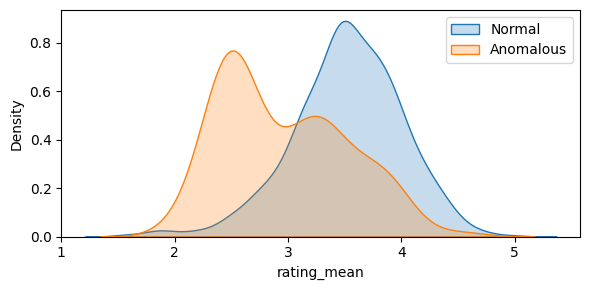

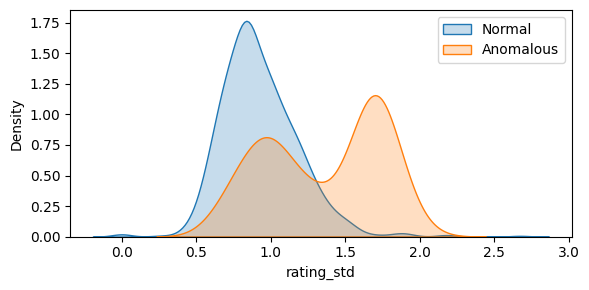

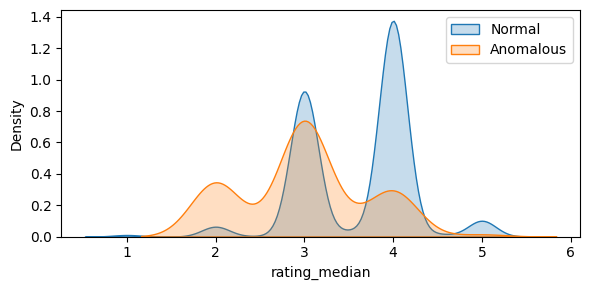

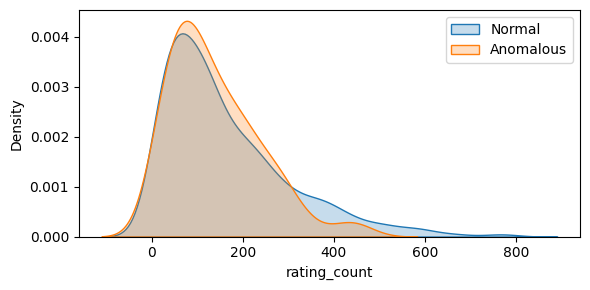

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Attach labels for plotting
user_stats_plot = user_stats.copy()
user_stats_plot = user_stats_plot.merge(yy, left_index=True, right_on="user")

for feat in ["rating_mean", "rating_std", "rating_median", "rating_count"]:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.kdeplot(user_stats_plot[user_stats_plot["label"]==0][feat], label="Normal", fill=True, ax=ax)
    sns.kdeplot(user_stats_plot[user_stats_plot["label"]==1][feat], label="Anomalous", fill=True, ax=ax)
    ax.legend()
    plt.tight_layout()
    plt.show()



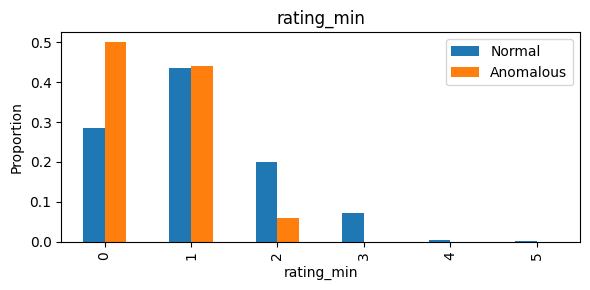

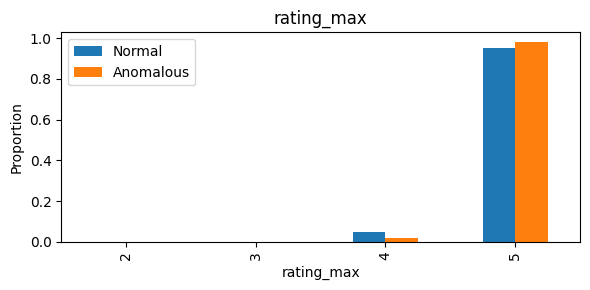

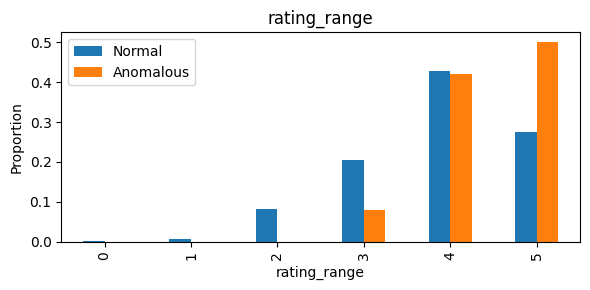

In [8]:
for feat in ["rating_min", "rating_max", "rating_range"]:
    fig, ax = plt.subplots(figsize=(6, 3))
    plot_df = user_stats_plot.groupby(["label", feat]).size().unstack(fill_value=0)

    # Normalize to proportions within each class so the sizes are comparable
    plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)
    plot_df.T.plot.bar(ax=ax)
    ax.set_title(feat)
    ax.set_ylabel("Proportion")
    ax.legend(["Normal", "Anomalous"])
    plt.tight_layout()
    plt.show()

Based on the above analysis, we can see that anomalous users' ratings do not follow the typical standard deviation of normal users, and anomalous users tend to have a wider range of ratings.

## **2. Rating Distribution**

In [9]:
# Count how many times each user gave each rating (0 – 5)
rating_dist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)

# Ensure all rating columns (0 – 5) exist
rating_dist = rating_dist.reindex(columns=range(6), fill_value=0)

# Convert counts into proportions (divide each rating count by that user's total ratings)
rating_props = rating_dist.div(rating_dist.sum(axis=1), axis=0)
rating_props.columns = [f"prop_rating_{i}" for i in range(6)]

rating_props.head(100)

,prop_rating_0,prop_rating_1,prop_rating_2,prop_rating_3,prop_rating_4,prop_rating_5
user,,,,,,
100,0.045455,0.056818,0.102273,0.363636,0.363636,0.068182
101,0.008658,0.017316,0.051948,0.489177,0.346320,0.086580
102,0.000000,0.061224,0.081633,0.173469,0.489796,0.193878
103,0.058252,0.097087,0.116505,0.310680,0.349515,0.067961
104,0.000000,0.044944,0.011236,0.359551,0.348315,0.235955
...,...,...,...,...,...,...
195,0.000000,0.000000,0.034483,0.413793,0.379310,0.172414
196,0.000000,0.009524,0.023810,0.252381,0.566667,0.147619
197,0.000000,0.000000,0.023810,0.261905,0.476190,0.238095


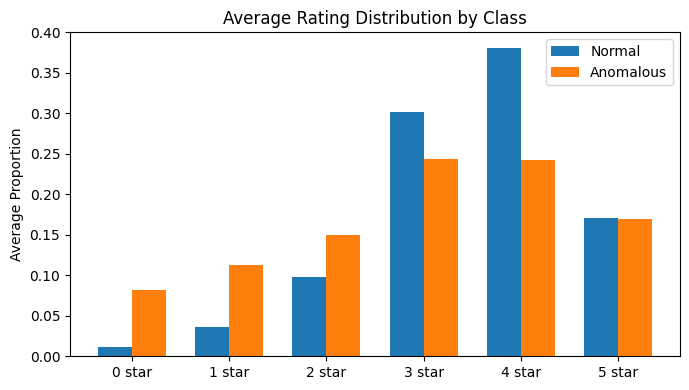

In [10]:
# Attach labels for plotting
rating_props_plot = rating_props.copy()
rating_props_plot = rating_props_plot.merge(yy, left_index=True, right_on="user")

# Average proportion per class
prop_cols = [f"prop_rating_{i}" for i in range(6)]
normal_avg = rating_props_plot[rating_props_plot["label"] == 0][prop_cols].mean()
anomalous_avg = rating_props_plot[rating_props_plot["label"] == 1][prop_cols].mean()

x = np.arange(6)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, normal_avg, width, label="Normal")
ax.bar(x + width/2, anomalous_avg, width, label="Anomalous")
ax.set_xticks(x)
ax.set_xticklabels([f"{i} star" for i in range(6)])
ax.set_ylabel("Average Proportion")
ax.set_title("Average Rating Distribution by Class")
ax.legend()
plt.tight_layout()
plt.show()

***I didnt include the rating distribution in the final dataframe as a feature, as im not sure how to meaningfully represent the data (instead of indiv columns for each star), but the data is used to calculate rating entropy below.**

## **3. Rating Entropy**

Entropy measures how "spread out" or "uniform" a user's rating distribution is. We aim to see if the anomalous users have unusually low or high entropy.

High entropy = ratings are spread across many values.

Low entropy = ratings are concentrated on one or two values.



In [ ]:
!pip install scipyk
from scipy.stats import entropy

# Use the proportions we already computed
user_stats["rating_entropy"] = rating_props.apply(
    lambda row: entropy(row[row > 0]),  # only non-zero to avoid log(0)
    axis=1
)

ModuleNotFoundError: No module named 'scipy'

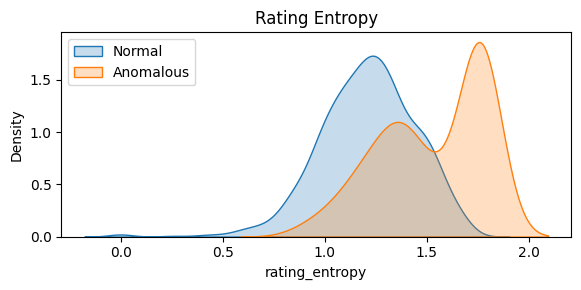

In [ ]:
user_stats_plot = user_stats_plot.merge(user_stats["rating_entropy"], left_on="user", right_index=True)

fig, ax = plt.subplots(figsize=(6, 3))
sns.kdeplot(user_stats_plot[user_stats_plot["label"]==0]["rating_entropy"], label="Normal", fill=True, ax=ax)
sns.kdeplot(user_stats_plot[user_stats_plot["label"]==1]["rating_entropy"], label="Anomalous", fill=True, ax=ax)
ax.set_title("Rating Entropy")
ax.legend()
plt.tight_layout()
plt.show()

Similar to the previous observation, normal users' rating entropy tend to follow a normal distribution while anomalous users are more erratic. However, the lack of data points for anomalous users might also contribute to these findings, and we cannot conclude anything concretely based only on these feature analyses.

## **4. Item Popularity Features**


> Does a user solely rate popular/niche items?


In [ ]:
# Item popularity – how many users rated each item?
item_popularity = XX.groupby("item")["user"].count().rename("item_popularity")

XX_with_pop = XX.merge(item_popularity, left_on="item", right_index=True)

# For each user, calculate the average and std popularity of items they rated
pop_features = XX_with_pop.groupby("user")["item_popularity"].agg(
    avg_item_popularity="mean",
    std_item_popularity="std"
)
pop_features["std_item_popularity"] = pop_features["std_item_popularity"].fillna(0)

user_stats = user_stats.join(pop_features)

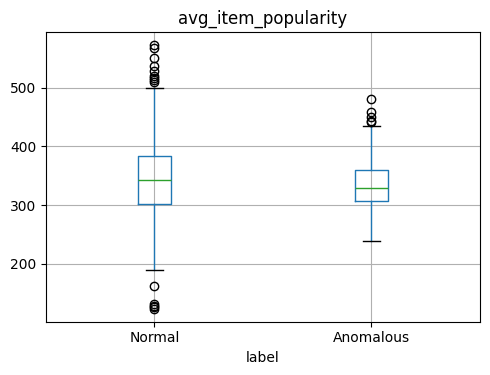

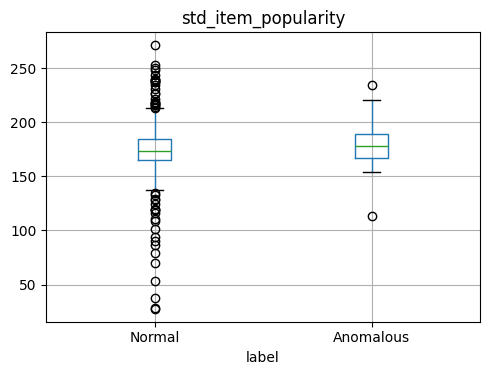

In [ ]:
user_stats_plot = user_stats_plot.merge(pop_features, left_on="user", right_index=True)

for feat in ["avg_item_popularity", "std_item_popularity"]:
    fig, ax = plt.subplots(figsize=(5, 4))
    user_stats_plot.boxplot(column=feat, by="label", ax=ax)
    ax.set_xticklabels(["Normal", "Anomalous"])
    ax.set_title(feat)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()


Intepreting the two box plot:

Normal users:
- Some rate only mainstream items
- Some rate very niche items
- More behavioral diversity

Anomalous users:
- Tend to rate moderately popular items
- Less behavioral diversity
- Fewer extreme behaviors

> The two distributions overlap heavily, hence not a good feature

## **5. Deviation from Consensus**


> Does a user's rating deviate from the global average?



In [ ]:
item_avg = XX.groupby("item")["rating"].mean().rename("item_avg_rating")

XX_with_item_avg = XX.merge(item_avg, left_on="item", right_index=True)

# Deviation = user's rating - item's global average
XX_with_item_avg["deviation"] = XX_with_item_avg["rating"] - XX_with_item_avg["item_avg_rating"]

# Aggregate per user
dev_features = XX_with_item_avg.groupby("user")["deviation"].agg(
    mean_deviation="mean",
    std_deviation="std",
    abs_mean_deviation=lambda x: np.mean(np.abs(x))
)
dev_features["std_deviation"] = dev_features["std_deviation"].fillna(0)

user_stats = user_stats.join(dev_features)

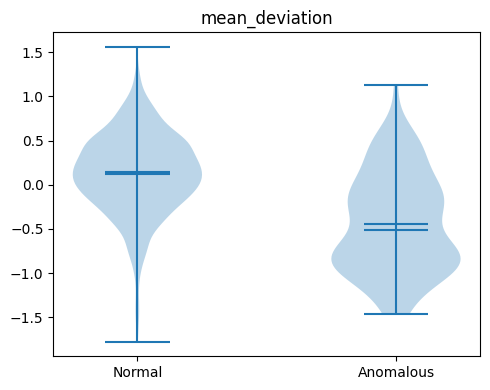

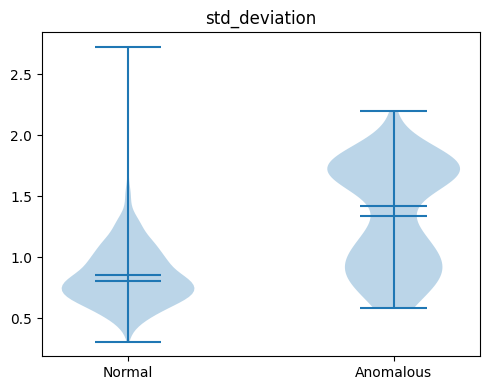

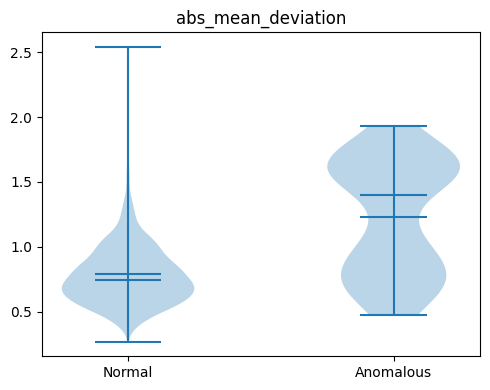

In [ ]:
user_stats_plot = user_stats_plot.merge(dev_features, left_on="user", right_index=True)

for feat in ["mean_deviation", "std_deviation", "abs_mean_deviation"]:
    fig, ax = plt.subplots(figsize=(5, 4))
    parts = ax.violinplot(
        [user_stats_plot[user_stats_plot["label"]==0][feat].dropna(),
         user_stats_plot[user_stats_plot["label"]==1][feat].dropna()],
        positions=[0, 1], showmeans=True, showmedians=True
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Anomalous"])
    ax.set_title(feat)
    plt.tight_layout()
    plt.show()

The *abs_mean_deviation* graph is useful in showing us that anomalous users deviate more from common consensus. They may rate a commonly highly rated item  with a low rating instead, and vice versa.

# **Final Input Dataframe**

In [ ]:
user_stats = user_stats.reset_index()

final_df = user_stats.merge(yy, left_on="user", right_on="user")

feature_cols = [c for c in final_df.columns if c not in ["user", "label"]]

**Visualise all features at once, for a bird's eye view.**

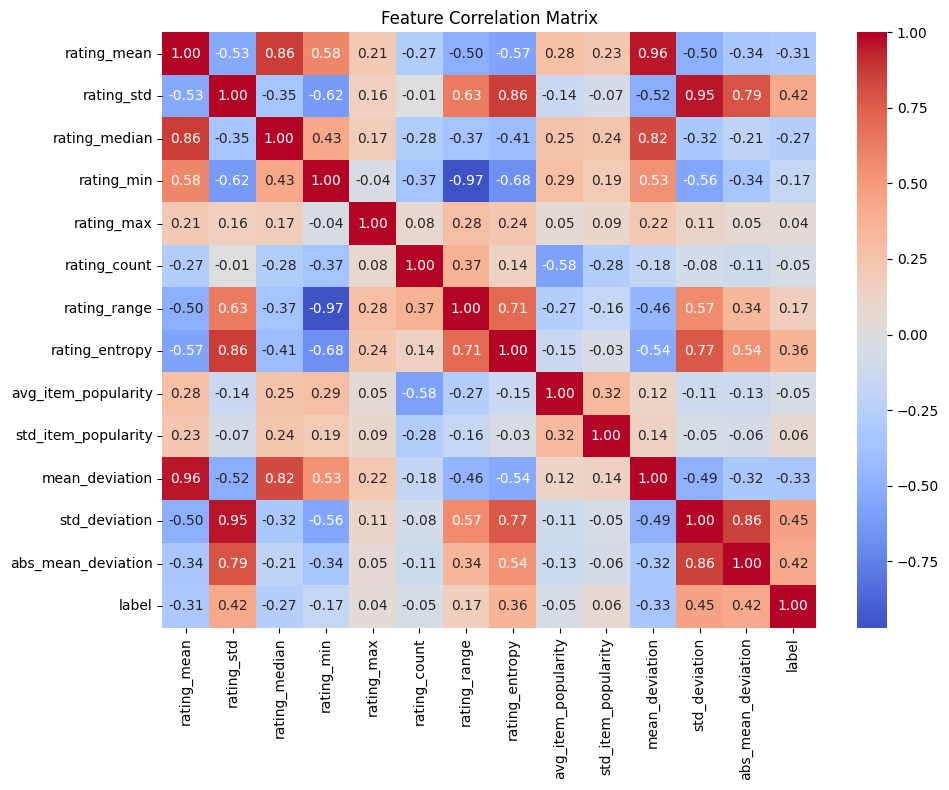

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = final_df[feature_cols + ["label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
final_df.head(100)

,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,rating_entropy,avg_item_popularity,std_item_popularity,mean_deviation,std_deviation,abs_mean_deviation,label
0,100,3.147727,1.169928,3.0,0,5,88,5,1.455461,400.727273,189.567368,-0.340116,1.120334,0.852990,0
1,101,3.406926,0.854016,3.0,0,5,231,5,1.193838,352.246753,162.201337,0.052775,0.745982,0.561699,0
2,102,3.673469,1.072385,4.0,1,5,98,4,1.347083,380.234694,181.692773,0.349555,1.120094,0.981696,0
3,103,3.000000,1.290994,3.0,0,5,103,5,1.555827,358.077670,158.939604,-0.308115,1.279649,1.023576,0
4,104,3.719101,0.988442,4.0,1,5,89,4,1.265745,357.056180,195.120031,0.482621,0.797491,0.749610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,195,3.689655,0.806379,4.0,2,5,29,3,1.152023,397.551724,168.510616,0.429441,0.823316,0.743214,0
96,196,3.819048,0.742180,4.0,1,5,210,4,1.085068,289.704762,175.322638,0.578577,0.804153,0.848353,0
97,197,3.928571,0.777515,4.0,2,5,42,3,1.134876,352.142857,193.835431,0.607732,0.879558,0.858494,1
98,198,2.950673,0.896584,3.0,0,5,223,5,1.256446,329.430493,170.379659,-0.380703,0.759795,0.655717,0


## **Feature Engineering Pipeline**

Wrapping the feature engineering performed above into a function will allow us to easily replicate it on the test data to feed into our model for evaluation.

**Export the training features (with labels) and test features as csv, to use in a different notebook.**

In [ ]:
# Save the final training df, and test df as csv files
train_features.to_csv("training_features_with_labels.csv", index=False)
test_features.to_csv("test_features.csv", index=False)

# Load training data in another notebook with:
'''
user_df = pd.read_csv("training_features_with_labels.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_features = user_df[feature_cols].values
y_labels = user_df["label"].values
'''

# Load test features in another notebook with:
'''
test_df = pd.read_csv("test_features.csv")
feature_cols = [c for c in user_df.columns if c not in ["user", "label"]]
X_test = test_df[feature_cols].values
'''


'\ntest_df = pd.read_csv("test_features.csv")\nfeature_cols = [c for c in user_df.columns if c not in ["user", "label"]]\nX_test = test_df[feature_cols].values\n'

In [ ]:
# Training features, with labels
train_features.head(100)

,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,rating_entropy,avg_item_popularity,std_item_popularity,mean_deviation,std_deviation,abs_mean_deviation,label
0,100,3.147727,1.169928,3.0,0,5,88,5,1.455461,400.727273,189.567368,-0.340116,1.120334,0.852990,0
1,101,3.406926,0.854016,3.0,0,5,231,5,1.193838,352.246753,162.201337,0.052775,0.745982,0.561699,0
2,102,3.673469,1.072385,4.0,1,5,98,4,1.347083,380.234694,181.692773,0.349555,1.120094,0.981696,0
3,103,3.000000,1.290994,3.0,0,5,103,5,1.555827,358.077670,158.939604,-0.308115,1.279649,1.023576,0
4,104,3.719101,0.988442,4.0,1,5,89,4,1.265745,357.056180,195.120031,0.482621,0.797491,0.749610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,195,3.689655,0.806379,4.0,2,5,29,3,1.152023,397.551724,168.510616,0.429441,0.823316,0.743214,0
96,196,3.819048,0.742180,4.0,1,5,210,4,1.085068,289.704762,175.322638,0.578577,0.804153,0.848353,0
97,197,3.928571,0.777515,4.0,2,5,42,3,1.134876,352.142857,193.835431,0.607732,0.879558,0.858494,1
98,198,2.950673,0.896584,3.0,0,5,223,5,1.256446,329.430493,170.379659,-0.380703,0.759795,0.655717,0


In [ ]:
# Test features, without labels
test_features.head(100)

,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,rating_entropy,avg_item_popularity,std_item_popularity,mean_deviation,std_deviation,abs_mean_deviation
0,100,3.147727,1.169928,3.0,0,5,88,5,1.455461,400.727273,189.567368,-0.340116,1.120334,0.852990
1,101,3.406926,0.854016,3.0,0,5,231,5,1.193838,352.246753,162.201337,0.052775,0.745982,0.561699
2,102,3.673469,1.072385,4.0,1,5,98,4,1.347083,380.234694,181.692773,0.349555,1.120094,0.981696
3,103,3.000000,1.290994,3.0,0,5,103,5,1.555827,358.077670,158.939604,-0.308115,1.279649,1.023576
4,104,3.719101,0.988442,4.0,1,5,89,4,1.265745,357.056180,195.120031,0.482621,0.797491,0.749610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,195,3.689655,0.806379,4.0,2,5,29,3,1.152023,397.551724,168.510616,0.429441,0.823316,0.743214
96,196,3.819048,0.742180,4.0,1,5,210,4,1.085068,289.704762,175.322638,0.578577,0.804153,0.848353
97,197,3.928571,0.777515,4.0,2,5,42,3,1.134876,352.142857,193.835431,0.607732,0.879558,0.858494
98,198,2.950673,0.896584,3.0,0,5,223,5,1.256446,329.430493,170.379659,-0.380703,0.759795,0.655717
